
# Spotify Music Recommendation System

**Objective:**
Build a content-based recommendation system that suggests
similar songs based on Spotify audio features.

> Workflow:

1. Load Dataset
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. Feature Scaling
6. KMeans Clustering
7. Cosine Similarity
8. Recommendation Function
9. Save Model


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.decomposition import PCA

import joblib


In [2]:
df = pd.read_csv("/kaggle/input/datasets/maharshipandya/-spotify-tracks-dataset/dataset.csv")

print("Shape :", df.shape)

df.head()

Shape : (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996


# Data Cleaning

In [5]:
df.drop(columns=["Unnamed: 0"], inplace=True)

print(df.shape)

(114000, 20)


In [6]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

artists       1
album_name    1
track_name    1
dtype: int64

In [7]:
df.dropna(inplace=True)

print(df.shape)

(113999, 20)


In [8]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 450


In [9]:
df.drop_duplicates(subset="track_id", inplace=True)

print(df.shape)

(89740, 20)


In [10]:
df.isnull().sum().sum()

np.int64(0)

# Exploratory Data Analysis (EDA)

In [11]:
numerical_columns = df.select_dtypes(include=np.number).columns

numerical_columns

Index(['popularity', 'duration_ms', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='object')

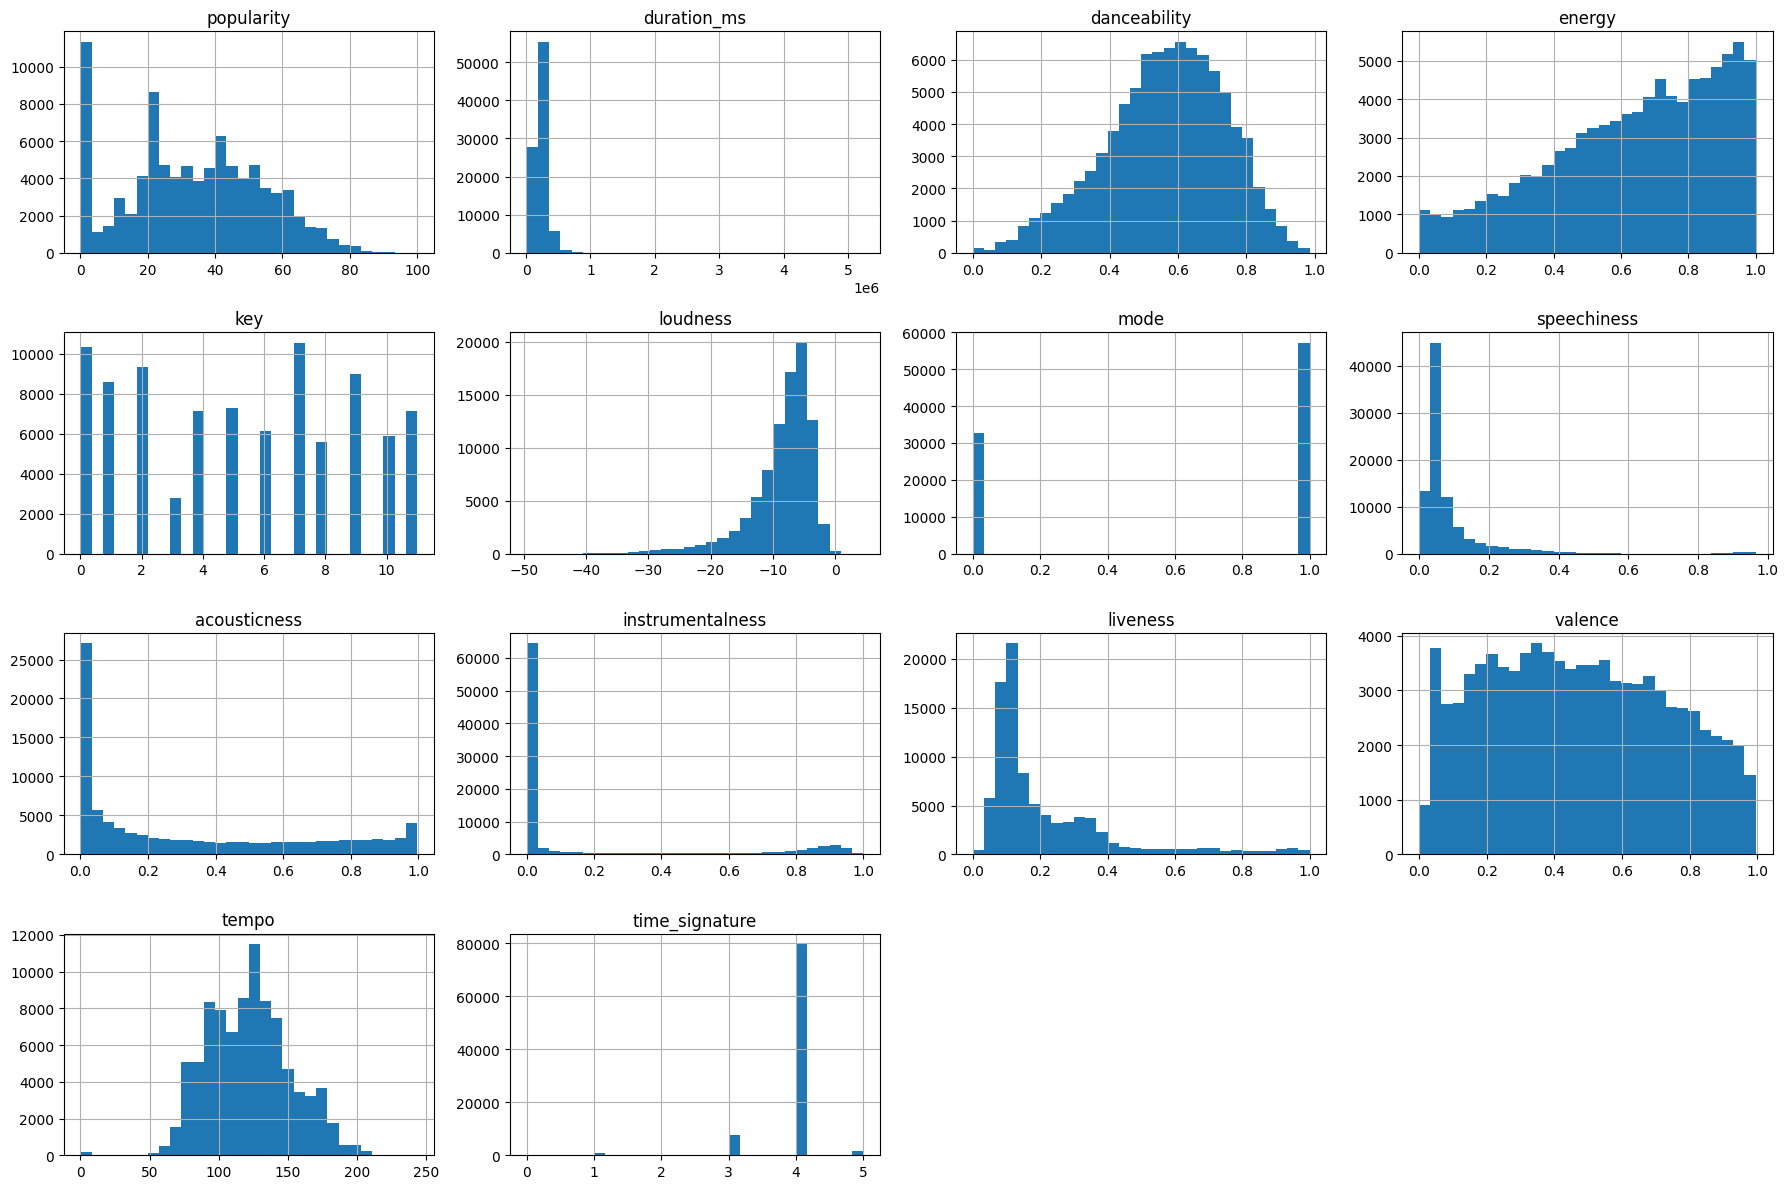

In [12]:
df[numerical_columns].hist(
    figsize=(18,12),
    bins=30
)

plt.tight_layout()

plt.show()

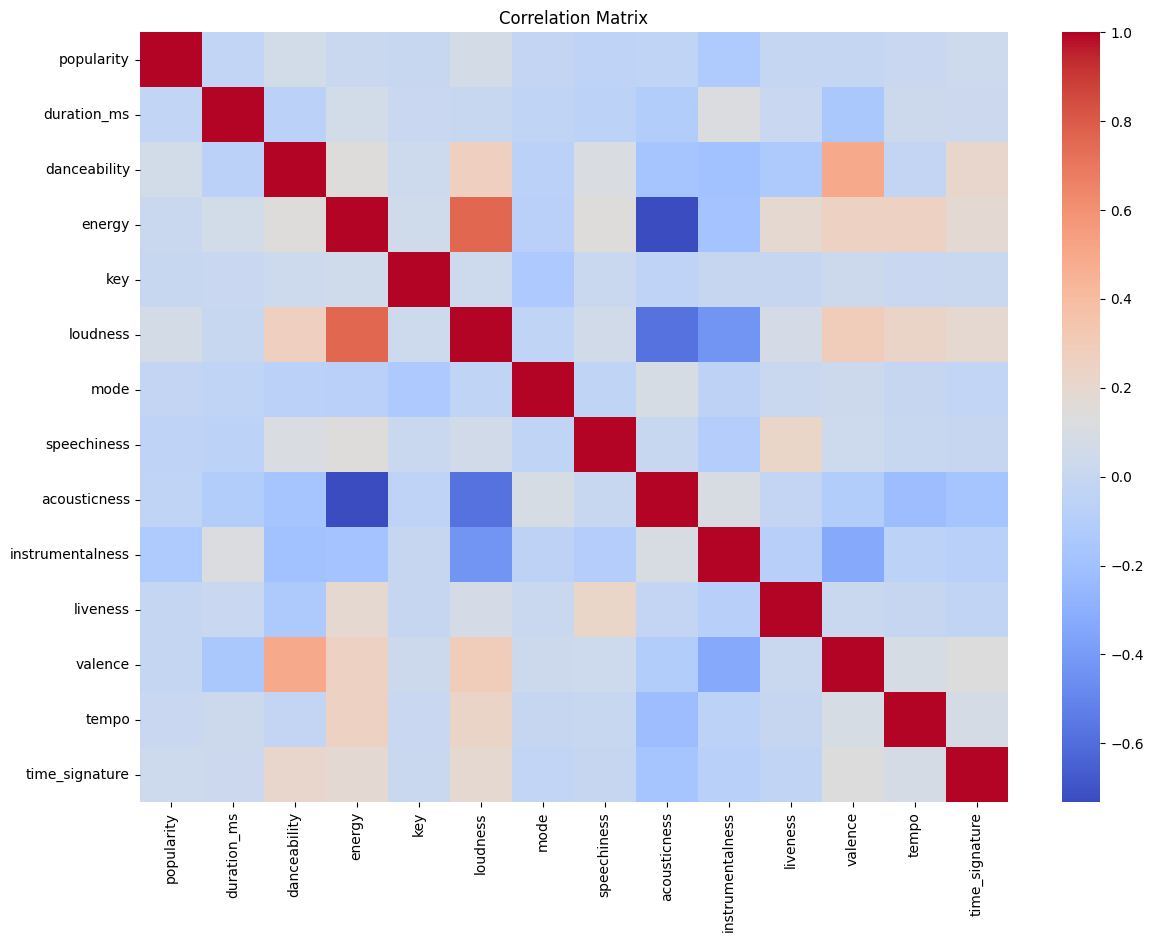

In [13]:
plt.figure(figsize=(14,10))

corr = df[numerical_columns].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

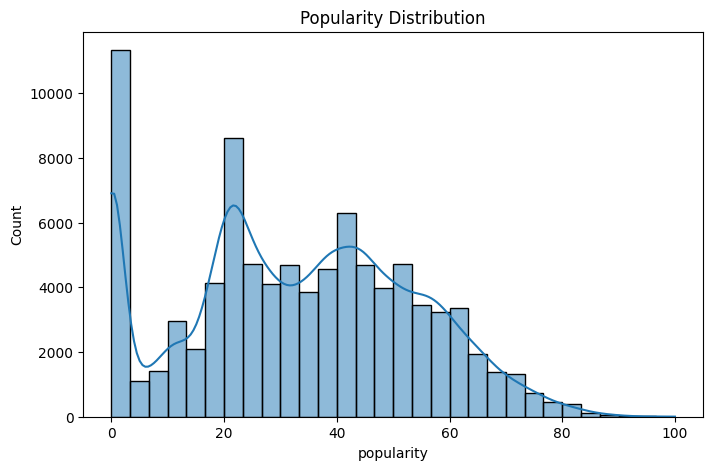

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["popularity"],
    bins=30,
    kde=True
)

plt.title("Popularity Distribution")

plt.show()

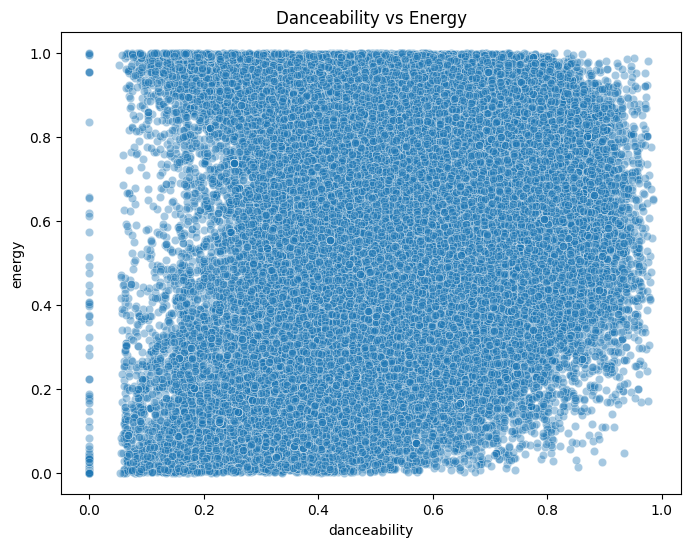

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="danceability",
    y="energy",
    alpha=0.4
)

plt.title("Danceability vs Energy")

plt.show()

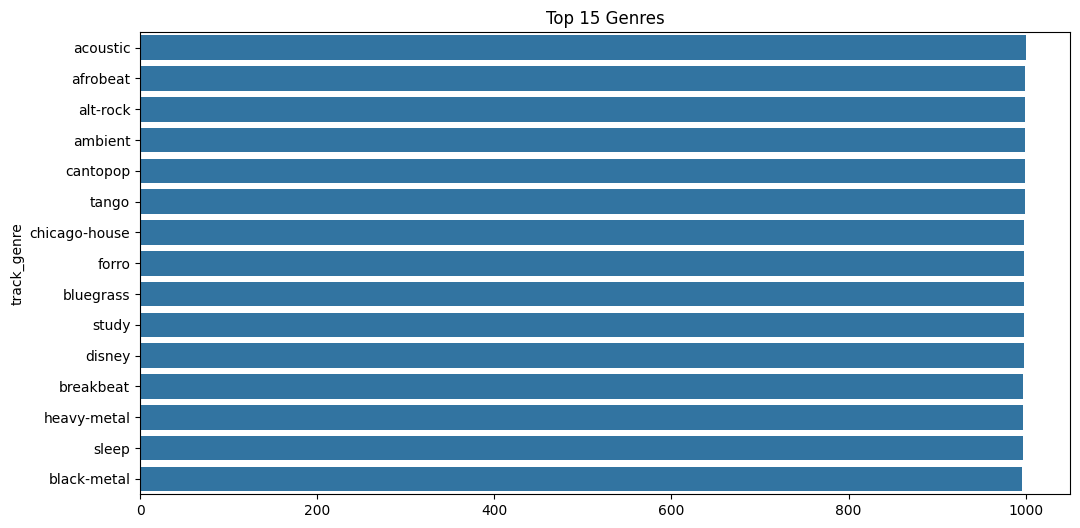

In [16]:
top_genres = (
    df["track_genre"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 15 Genres")

plt.show()

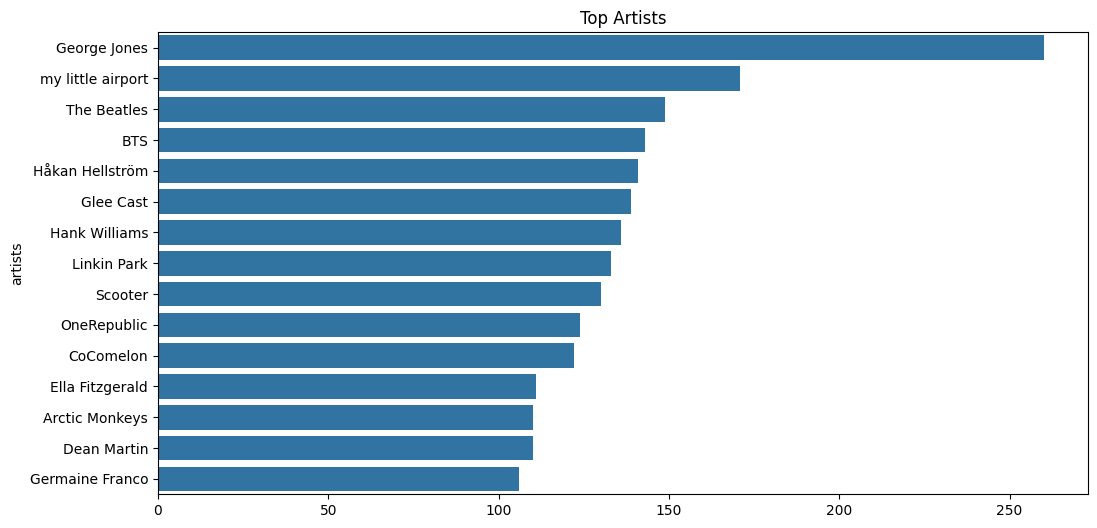

In [17]:
top_artists = (
    df["artists"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_artists.values,
    y=top_artists.index
)

plt.title("Top Artists")

plt.show()

# Feature Selection


In [18]:
features = [

    "danceability",

    "energy",

    "loudness",

    "speechiness",

    "acousticness",

    "instrumentalness",

    "liveness",

    "valence",

    "tempo",

    "duration_ms"

]

In [19]:
X = df[features]

X.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917,230666
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489,149610
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332,210826
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740,201933
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949,198853


In [20]:
print(X.shape)

(89740, 10)


# Feature Scaling

In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled Shape :", X_scaled.shape)


Scaled Shape : (89740, 10)


# Finding the Optimal Number of Clusters (Elbow Method)

In [22]:
inertia = []

cluster_range = range(2,21)

for k in cluster_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

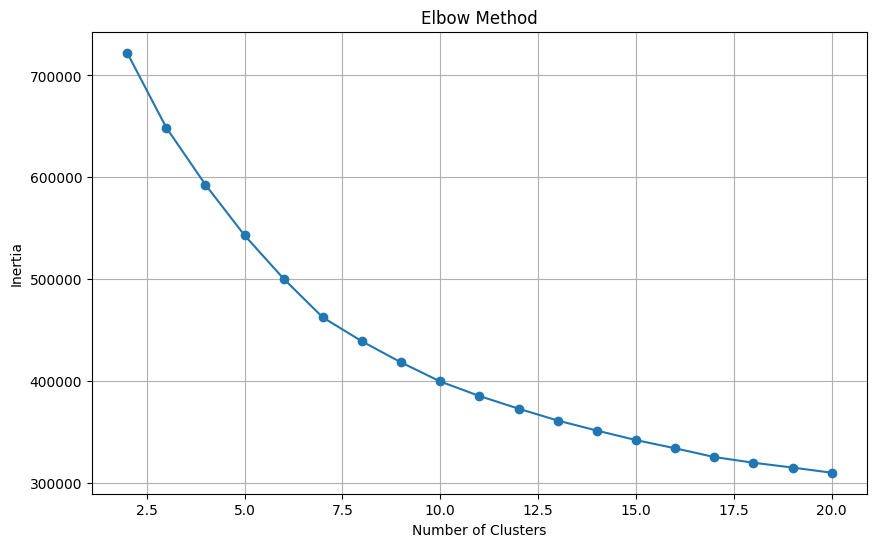

In [23]:
plt.figure(figsize=(10,6))

plt.plot(
    cluster_range,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

# Silhouette Score

In [24]:
scores = []

cluster_range = range(2, 13)

for k in cluster_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels,
        sample_size=10000,
        random_state=42
    )

    scores.append(score)
    print(f"k={k}, silhouette={score:.4f}")

k=2, silhouette=0.2507
k=3, silhouette=0.1533
k=4, silhouette=0.1602
k=5, silhouette=0.1641
k=6, silhouette=0.1713
k=7, silhouette=0.1757
k=8, silhouette=0.1761
k=9, silhouette=0.1590
k=10, silhouette=0.1624
k=11, silhouette=0.1495
k=12, silhouette=0.1519


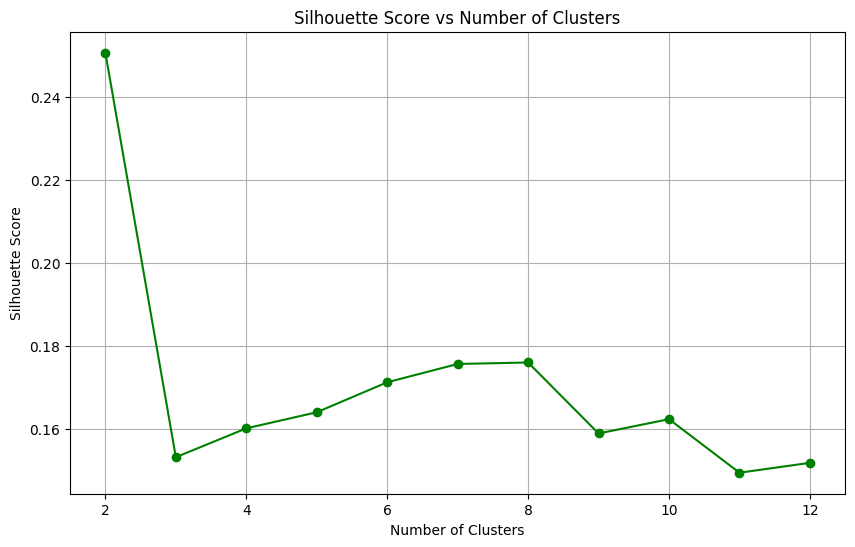

In [25]:
plt.figure(figsize=(10,6))

plt.plot(
    cluster_range,
    scores,
    marker="o",
    color="green"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Score vs Number of Clusters")

plt.grid(True)

plt.show()

# Train the K-Means Model

**Fix:** with the corrected feature set, `k = 8` gives the best silhouette score (0.176, vs. 0.162 at k=10 and worse elsewhere) — updated from the original k=10.

In [26]:
kmeans = KMeans(
    n_clusters= 8,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

print("Model Trained Successfully!")

Model Trained Successfully!


In [27]:
df["cluster"] = clusters

df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,5
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,6
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,6
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,6
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,6


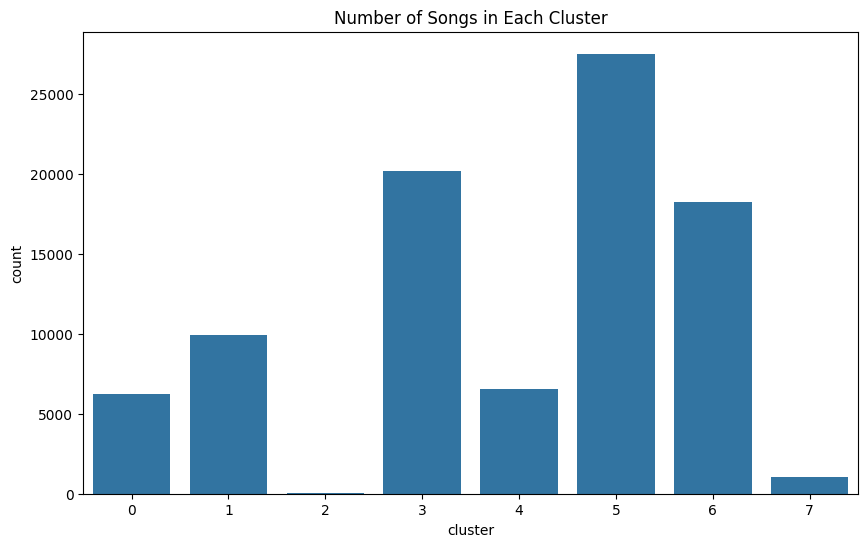

In [28]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="cluster"
)

plt.title("Number of Songs in Each Cluster")

plt.show()

In [29]:
df["cluster"].value_counts().sort_index()

cluster
0     6226
1     9941
2       40
3    20210
4     6529
5    27530
6    18224
7     1040
Name: count, dtype: int64

# Visualizing Clusters using PCA

In [30]:
pca = PCA(n_components=2)

reduced_features = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    reduced_features,
    columns=["PC1","PC2"]
)

pca_df["cluster"] = clusters

pca_df.head()

,PC1,PC2,cluster
0,0.688203,1.008627,5
1,-3.182105,1.306311,6
2,-1.315151,-0.170218,6
3,-3.186986,-0.240440,6
4,-0.884286,0.302659,6


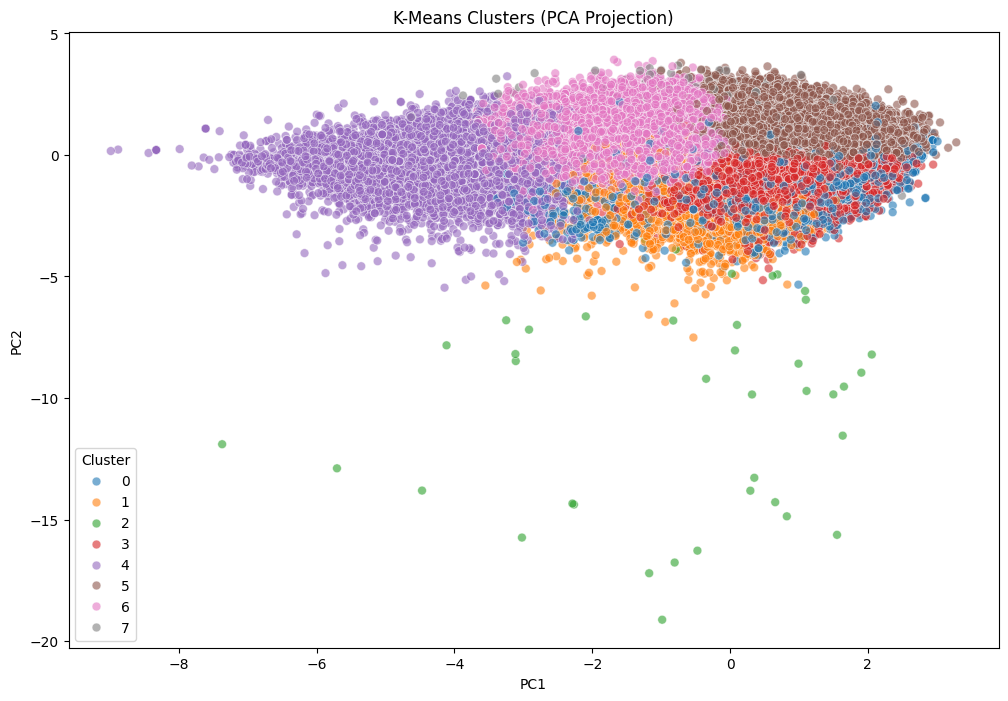

In [31]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.6,
    s=40
)

plt.title("K-Means Clusters (PCA Projection)")

plt.legend(title="Cluster")

plt.show()

In [32]:
joblib.dump(scaler, "scaler.joblib")
joblib.dump(kmeans, "kmeans.joblib")

print("Models Saved Successfully!")

Models Saved Successfully!


# Cosine Similarity & Recommendation Function

**Fix:** the original version precomputed a full N×N cosine similarity matrix for every cluster and kept it in memory. One cluster here has 27,530 songs — an N×N matrix for that alone is ~6 GB. Instead, we store each cluster's *scaled feature matrix* (O(n) memory) and compute similarity for a single query song on demand (`1 x N` comparison), which is what `recommend()` below does.

`recommend()` also takes an optional `restrict_genre` argument, so recommendations can be kept within the searched song's genre instead of matching on audio features alone across every genre/language in the dataset.

In [33]:
feature_columns = features  # same list used for scaling/clustering above

scaled_clusters = {}

for cluster_id in sorted(df["cluster"].unique()):

    cluster_df = df[df["cluster"] == cluster_id]

    scaled_clusters[cluster_id] = scaler.transform(
        cluster_df[feature_columns]
    )

In [34]:
def recommend(song_name, artist_name=None, n=10, restrict_genre=None):

    """
    song_name : track name to search for
    artist_name : disambiguates when multiple artists have a song with the same name
                  (recommended — pass this whenever you know it)
    n : number of recommendations to return
    restrict_genre : if set (e.g. "indian"), only recommend songs from that genre.
                      If None, recommends purely by audio similarity across all genres.
    """

    matches = df[df["track_name"].str.lower() == song_name.lower()]

    if artist_name is not None:
        matches = matches[matches["artists"] == artist_name]

    if matches.empty:
        print("Song not found!")
        return []

    idx = matches.index[0]

    cluster = df.loc[idx, "cluster"]

    cluster_df = df[df["cluster"] == cluster].copy()

    cluster_scaled = scaled_clusters[cluster]

    local_idx = cluster_df.index.get_loc(idx)

    similarity = cosine_similarity(
        cluster_scaled[local_idx].reshape(1, -1),
        cluster_scaled
    ).flatten()

    scores = list(enumerate(similarity))

    if restrict_genre:
        allowed_positions = set(
            cluster_df.index.get_loc(i)
            for i in cluster_df[cluster_df.track_genre == restrict_genre].index
        )
        scores = [(i, s) for i, s in scores if i in allowed_positions]

    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    recommendations = []
    seen = set()

    for i, score in scores:

        song = cluster_df.iloc[i]

        key = (song.track_name, song.artists)

        if key in seen:
            continue

        seen.add(key)

        if song.track_name.lower() == song_name.lower():
            continue

        recommendations.append((song, score))

        if len(recommendations) == n:
            break

    return recommendations

# Test the Recommendation System

In [35]:
for song, score in recommend("Believer", n=10):
    print(f"{score:.4f}  {song.track_name} — {song.artists}  [{song.track_genre}]")

0.9960  Rav — The Minds Of 99  [punk-rock]
0.9930  Ghost Assassin - Original Mix — Maduk;Veela  [drum-and-bass]
0.9924  Thinkin About - T & Sugah Remix — ShockOne;Lee Mvtthews;T & Sugah  [drum-and-bass]
0.9922  Crash & Burn — Tweekacore;Darren Styles;Giin  [happy]
0.9919  Stil in Mij — Barry Fest;The Festy Boys  [hardstyle]
0.9883  Stickup — Get Dead  [acoustic]
0.9863  Nobody To Love - Extended Mix — Sigma  [drum-and-bass]
0.9855  Go — Maduk;Lachi  [drum-and-bass]
0.9854  By Your Side — Friction;Flowidus;Raphaella  [drum-and-bass]
0.9851  Take Me Home (feat. Jem Cooke) (Protostar Remix) — Delta Heavy;Jem Cooke;Protostar  [drum-and-bass]


In [36]:
for song, score in recommend("Shape of You", n=10):
    print(f"{score:.4f}  {song.track_name} — {song.artists}  [{song.track_genre}]")

0.9704  Overture in the French Style, Op. 2, BWV 831 (Excerpts): XI. Echo — Johann Sebastian Bach;Orion Weiss  [classical]
0.9651  Old Pine Box — Andrew Marlin  [bluegrass]
0.9645  This Here — Bobby Timmons  [piano]
0.9629  Amaneci En Tus Brazos — Chamin Madero  [guitar]
0.9582  Brasileirinho — Eudóxia De Barros  [piano]
0.9580  Memories (Instrumental Guitar) — Guus Dielissen  [acoustic]
0.9576  Linus And Lucy — Vince Guaraldi Trio  [jazz]
0.9569  Oh Odessa — Cluster  [industrial]
0.9565  Histoire du tango: I. Bordel 1900 — Astor Piazzolla;Nora Lee García;Rene Izquierdo  [tango]
0.9555  Every Breath You Take — Joseph Sullinger  [guitar]


In [37]:
for song, score in recommend("Aaftaab", artist_name="The Local Train", n=10):
    print(f"{score:.4f}  {song.track_name} — {song.artists}  [{song.track_genre}]")

0.9870  Dunay goluboy — Vladimir Nechaev  [romance]
0.9841  年度之歌 — Kay Tse  [cantopop]
0.9825  Puente de Piedra — Los Chicanos  [rock-n-roll]
0.9819  Boiada — Almir Sater  [folk]
0.9788  Brodjaga — Zhanna Bichevskaya  [romance]
0.9787  Einsames Gewand — Spotlight Musicals;Sabrina Weckerlin;Dennis Martin  [show-tunes]
0.9779  Hopeinen kuu - Guarda che luna — Olavi Virta  [tango]
0.9756  Поручик Голицын — Zhanna Bichevskaya;Gennadiy Ponomarjov  [romance]
0.9752  Carinhoso — Elis Regina  [jazz]
0.9744  While Waiting — Greensky Bluegrass  [bluegrass]


In [38]:
# Same search, but staying within the source genre
for song, score in recommend("Aaftaab", artist_name="The Local Train", n=10, restrict_genre="indian"):
    print(f"{score:.4f}  {song.track_name} — {song.artists}  [{song.track_genre}]")

0.9412  Jab Koi Baat X 500 Miles — Pranish VP  [indian]
0.9406  Lamhe — Raghav Chaitanya  [indian]
0.9309  Kitna Hai Pyaar — Ashu Shukla  [indian]
0.9307  Betahasha — Akanksha Bhandari;Nilotpal Sinha  [indian]
0.9295  Baarishein — Anuv Jain  [indian]
0.9278  Arcade X Dil Ko Karaar Aaya — Pranish VP  [indian]
0.9245  Ka Karoon Sajni Guitar — Sunil Ganguly  [indian]
0.9231  Channa Mereya - Unplugged — Pritam;Arijit Singh  [indian]
0.9168  Kal Ki Hi Baat Hai — Pritam;KK  [indian]
0.9137  Maula — Anuv Jain  [indian]


# Save the Clustered Dataset

In [39]:
df.to_csv(
    "spotify_clustered_dataset.csv",
    index=False
)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!
